In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, Lasso
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from statsmodels.stats.mediation import Mediation
from sklearn.svm import SVR
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats import pearsonr
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

# 1 Load validation set

In [118]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_val_test.pkl")
main_test = pd.DataFrame(main_test)

# 2 Preprocessing

## 2.1 Education preprocessing

In [119]:
edu = main_test[main_test["EDUL"]=="Prefer not to answer"].index
main_test = main_test.drop(edu)
print("People removed due to mising education", len(edu))

People removed due to mising education 11


## 2.2 Recoding

In [120]:
# recoding imaging site and gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
main_test['EDUL'] = main_test['EDUL'].map({'None of the above': 0, 'Other professional qualifications eg: nursing, teaching': 5,'NVQ or HND or HNC or equivalent': 4, 'CSEs or equivalent': 1, 'O levels/GCSEs or equivalent':2, 'A levels/AS levels or equivalent':3,'College or University degree':6})
main_test["Sex"] = main_test["Sex"].map({"Female":0, "Male":1})
main_test["Sex"] = main_test["Sex"].astype("int")

main_test = pd.get_dummies(main_test, columns=["IS"], prefix="IS", drop_first=True)

# delete unnecessary variables
del main_test["ID"]
del main_test["MVPA"]
del main_test["TPA"]

## 2.3 Remove outliers on SRPA

In [121]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 526
5447


## 2.4 Convert SRPA from MET min/week to min/week

In [122]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

# 3 Basic distributions of validation set

## 3.1 Data and Descriptives

In [123]:
main_test.head()

,Age,Sex,VPA,MPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,EDUL,BA,IS_1,IS_2,IS_3
4723,73.0,0,59.2704,661.8528,2400.4512,315.0,90.0,0.0,20.0,52.0,25.1338,74.0,137.0,2.0,0.055721,0,0,0
25494,55.0,1,70.0560,970.7760,1991.5920,120.0,30.0,0.0,26.0,55.0,22.9630,80.0,148.0,6.0,-0.861604,0,0,0
34463,65.0,0,48.6720,506.1888,2813.2416,420.0,840.0,160.0,22.0,45.0,23.8325,63.0,108.0,0.0,-7.381719,1,0,0
26337,67.0,0,0.0000,60.4800,1653.1200,40.0,60.0,0.0,38.0,68.0,33.6473,84.0,139.0,6.0,6.851578,0,1,0
29224,70.0,0,9.2736,361.6704,1873.2672,30.0,0.0,45.0,24.0,69.0,32.8906,87.0,132.0,5.0,3.297208,1,0,0


In [124]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Sex"] == 0]
male = main_test[main_test["Sex"]== 1]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

#print("IS")
#print(main_test["IS"].value_counts())

print("EDU")
print(main_test["EDUL"].value_counts())

Number of females: 2967
NUmber of males: 2480
Age
Mean 64.1918487240683
Std 7.813217495024637
LPA
Mean 1981.2956219570403
Std 417.0349615013914
MPA
Mean 482.63231665136783
Std 216.91206762234404
VPA
Mean 34.28457058931525
Std 43.27238176765399
SRLPA
Mean 235.36497154396915
Std 219.148059340486
SRMPA
Mean 159.23480815127593
Std 192.25611565481896
SRVPA
Mean 66.4734716357628
Std 83.85247296911109
DBP
Mean 81.12153478979255
Std 10.361812499540996
SBP
Mean 136.32109418028273
Std 18.226970116831307
BMI
Mean 26.363390324949517
Std 4.2137193178246655
HG
Mean 33.494767762070865
Std 10.811896177355372
HR
Mean 67.96952450890399
Std 11.047097626491741
EDU
6.0    2709
2.0    1029
3.0     771
4.0     269
5.0     257
0.0     220
1.0     192
Name: EDUL, dtype: int64


## 3.2 Physical activity

In [125]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

# plt.figure()
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,5000,1000),fontsize = 14)
# plt.ylim(0,0.01)
# plt.ylabel("Density",fontsize = 16)
# plt.yticks(fontsize = 14)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2000,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,4500,1000),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
# plt.ylim(0,0.01)
# plt.xticks(range(0,1500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
# plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
# plt.ylabel("Self-reported (min/week)", fontsize = 16)
# plt.xlabel("Accelerometer (min/week)", fontsize = 16)
# plt.xticks(fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.legend(loc="best")
# plt.show()

# 4 Reorder Dataframe

In [126]:
main_test = main_test[['Age', 'Sex', 'IS_1', "IS_2", "IS_3" , "EDUL", 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

# 5 Standardization of all variables

In [127]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex", 'IS_1', "IS_2", "IS_3", "EDUL"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex", 'IS_1', "IS_2", "IS_3", "EDUL"]], nan_policy='omit')

# 6 Correlation Heatmap

In [128]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

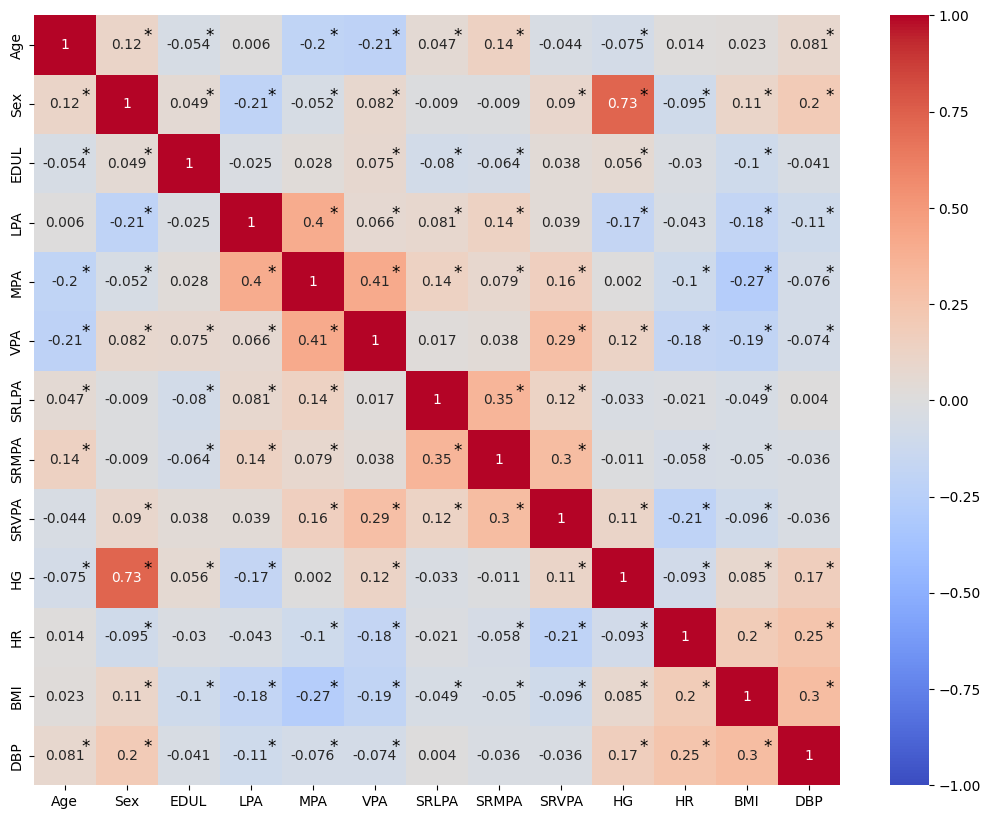

In [129]:
corr_test = main_test
corr_test = corr_test[:]
del corr_test["BA"]
del corr_test["SBP"]
del corr_test["IS_1"]
del corr_test["IS_2"]
del corr_test["IS_3"]
corr = corr_test.corr()
corr = round(corr,3)

fig, ax = plt.subplots(figsize=(13,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)


p_values = np.asarray(calculate_pvalues(corr_test))

threshold = 0.0007575  # Define your significance threshold

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            correlation = corr.iloc[i, j]
            p_value = p_values[i,j]  # Calculate or provide the p-value for the correlation

            if p_value < threshold:
                ax.text(j + 0.9, i + 0.2, "*", ha='right', va='top', color='black', fontsize=12)
                
plt.savefig('eduvalheatmap.png', format='png', dpi=800)               
plt.show()

# 7 Models with OLS

## 7.1 Baseline Covariates

In [130]:
cov_model = ols('BA ~ Sex + Age + IS_1 + IS_2 + IS_3 + EDUL', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     10.32
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           2.13e-11
Time:                        15:01:07   Log-Likelihood:                -17366.
No. Observations:                5447   AIC:                         3.475e+04
Df Residuals:                    5440   BIC:                         3.479e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0252      0.080      0.317      0.7

## 7.2 Accelerometer PA

In [131]:
lpa = ols('BA ~ LPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:LPA + EDUL:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     7.415
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           7.81e-11
Time:                        15:01:08   Log-Likelihood:                -17363.
No. Observations:                5447   AIC:                         3.475e+04
Df Residuals:                    5437   BIC:                         3.481e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0270      0.081      0.332      0.7

In [132]:
mpa = ols('BA ~ MPA + Sex + Age + EDUL + IS_1 + IS_2 + IS_3 + Sex:MPA + EDUL:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     8.637
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           5.72e-13
Time:                        15:01:08   Log-Likelihood:                -17358.
No. Observations:                5447   AIC:                         3.474e+04
Df Residuals:                    5437   BIC:                         3.480e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0135      0.080      0.170      0.8

In [133]:
vpa = ols('BA ~ VPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:VPA + EDUL:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     7.707
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           2.43e-11
Time:                        15:01:08   Log-Likelihood:                -17362.
No. Observations:                5447   AIC:                         3.474e+04
Df Residuals:                    5437   BIC:                         3.481e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0349      0.080      0.435      0.6

## 7.3 Self-report PA

In [134]:
srlpa = ols('BA ~ SRLPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + EDUL:SRLPA + Sex:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     7.569
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           4.22e-11
Time:                        15:01:08   Log-Likelihood:                -17363.
No. Observations:                5447   AIC:                         3.475e+04
Df Residuals:                    5437   BIC:                         3.481e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0404      0.080      0.507      0.6

In [135]:
srmpa = ols('BA ~ SRMPA + Sex + Age + IS_1 + IS_2 + IS_3 + EDUL + EDUL:SRMPA + Sex:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     8.503
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           9.84e-13
Time:                        15:01:08   Log-Likelihood:                -17358.
No. Observations:                5447   AIC:                         3.474e+04
Df Residuals:                    5437   BIC:                         3.480e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0434      0.080      0.545      0.5

In [136]:
srvpa = ols('BA ~ SRVPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + EDUL:SRVPA + Sex:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     6.945
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           5.07e-10
Time:                        15:01:08   Log-Likelihood:                -17365.
No. Observations:                5447   AIC:                         3.475e+04
Df Residuals:                    5437   BIC:                         3.482e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0301      0.080      0.377      0.7

# 8 Model comparisons

## 8.1 Cov vs. PA

In [137]:
model_comparison = anova_lm(cov_model, lpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5440.0  187437.131879      0.0         NaN       NaN       NaN
1    5437.0  187272.448880      3.0  164.682999  1.593723  0.188673


In [138]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5440.0  187437.131879      0.0         NaN       NaN       NaN
1    5437.0  186898.826765      3.0  538.305114  5.219874  0.001345


In [139]:
model_comparison = anova_lm(cov_model, vpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5440.0  187437.131879      0.0         NaN       NaN       NaN
1    5437.0  187183.090344      3.0  254.041535  2.459666  0.060868


## 8.2 Cov vs. SRPA

In [140]:
model_comparison = anova_lm(cov_model, srlpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5440.0  187437.131879      0.0         NaN       NaN       NaN
1    5437.0  187225.318385      3.0  211.813495  2.050346  0.104622


In [141]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5440.0  187437.131879      0.0         NaN       NaN       NaN
1    5437.0  186939.773834      3.0  497.358045  4.821759  0.002355


In [142]:
model_comparison = anova_lm(cov_model, srvpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5440.0  187437.131879      0.0        NaN       NaN       NaN
1    5437.0  187416.481160      3.0  20.650719  0.199694  0.896637


# 10 Mediation analysis

## 10.1 BMI

In [143]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
# print(res.summary())

In [144]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

modelm = ols("BMI ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ BMI + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.073064       -0.119106       -0.026628    0.004
ACME (treated)           -0.073064       -0.119106       -0.026628    0.004
ADE (control)            -0.168332       -0.331100        0.000614    0.054
ADE (treated)            -0.168332       -0.331100        0.000614    0.054
Total effect             -0.241396       -0.399906       -0.069902    0.008
Prop. mediated (control)  0.299369        0.095583        0.951885    0.012
Prop. mediated (treated)  0.299369        0.095583        0.951885    0.012
ACME (average)           -0.073064       -0.119106       -0.026628    0.004
ADE (average)            -0.168332       -0.331100        0.000614    0.054
Prop. mediated (average)  0.299369        0.095583        0.951885    0.012
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.095
Model:

In [145]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
# print(res.summary())

## 10.2 DBP

In [146]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
# print(res.summary())

In [147]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

modelm = ols("DBP ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ DBP + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.027833       -0.054160       -0.005596    0.014
ACME (treated)           -0.027833       -0.054160       -0.005596    0.014
ADE (control)            -0.218173       -0.375874       -0.073606    0.004
ADE (treated)            -0.218173       -0.375874       -0.073606    0.004
Total effect             -0.246006       -0.408018       -0.094742    0.002
Prop. mediated (control)  0.112137        0.022139        0.319531    0.016
Prop. mediated (treated)  0.112137        0.022139        0.319531    0.016
ACME (average)           -0.027833       -0.054160       -0.005596    0.014
ADE (average)            -0.218173       -0.375874       -0.073606    0.004
Prop. mediated (average)  0.112137        0.022139        0.319531    0.016
                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.051
Model:

In [148]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
# print(res.summary())

## 10.3 Heart rate

In [149]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
# print(res.summary())

In [150]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HR ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HR + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.031534       -0.055065       -0.011967    0.000
ACME (treated)           -0.031534       -0.055065       -0.011967    0.000
ADE (control)            -0.206350       -0.369341       -0.052304    0.012
ADE (treated)            -0.206350       -0.369341       -0.052304    0.012
Total effect             -0.237884       -0.401713       -0.083506    0.000
Prop. mediated (control)  0.133096        0.048269        0.410331    0.000
Prop. mediated (treated)  0.133096        0.048269        0.410331    0.000
ACME (average)           -0.031534       -0.055065       -0.011967    0.000
ADE (average)            -0.206350       -0.369341       -0.052304    0.012
Prop. mediated (average)  0.133096        0.048269        0.410331    0.000
                            OLS Regression Results                            
Dep. Variable:                     HR   R-squared:                       0.023
Model:

In [151]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
# print(res.summary())

## 10.4 Hand grip

In [152]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
# print(res.summary())

In [153]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA + Sex + IS_1 + IS_2 + IS_3 + EDUL + Age", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA + Sex + IS_1 + IS_2 + IS_3 + EDUL + Age", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HG ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HG + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.002507       -0.013096        0.005517    0.528
ACME (treated)           -0.002507       -0.013096        0.005517    0.528
ADE (control)            -0.242990       -0.404577       -0.080838    0.006
ADE (treated)            -0.242990       -0.404577       -0.080838    0.006
Total effect             -0.245497       -0.407947       -0.077791    0.006
Prop. mediated (control)  0.007785       -0.030246        0.073098    0.530
Prop. mediated (treated)  0.007785       -0.030246        0.073098    0.530
ACME (average)           -0.002507       -0.013096        0.005517    0.528
ADE (average)            -0.242990       -0.404577       -0.080838    0.006
Prop. mediated (average)  0.007785       -0.030246        0.073098    0.530
                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.564
Model:

In [154]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + VPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ VPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
# print(res.summary())

# 11 LASSO Regression

## 11.1 Accelerometer PA

Optimal alpha: 0.014174741629268055


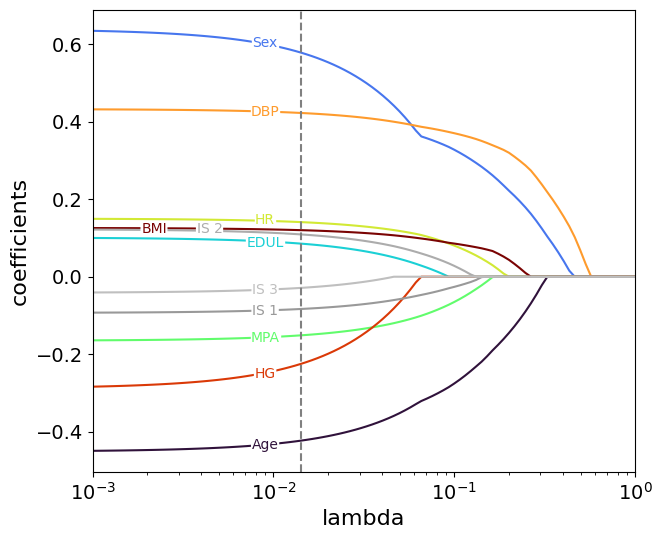

[-0.42333845  0.57885158  0.0855125  -0.15136991  0.1410529   0.42289488
 -0.22516339  0.1202472  -0.08330132  0.10928448 -0.0288568 ]
0.021682719121918992


In [155]:
df = main_test[["Age","Sex", "EDUL", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA", "IS_1", "IS_2", "IS_3"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Sex", "EDUL", "MPA", "HR", "DBP", "HG", "BMI", "IS_1", "IS_2", "IS_3"]]
Y = df["BA"]
columns = ["Age","Sex", "EDUL", "MPA", "HR", "DBP", "HG", "BMI", "IS 1", "IS 2", "IS 3"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas, random_state=888).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)



cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,6))
grey_shades = np.linspace(0.6, 0.75, 3)  # Three shades of mid-grey

num_colorful = 8  # First 7 columns use the colormap
num_grey = 3  # Last 3 columns use shades of grey

for i, column in enumerate(columns):
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3  # Different grey shades for last 3
    
    plt.plot(alphas, coefs[column], label=column, color=color)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3

    if i == 0:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -6),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, 4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -5),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(-80, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 9:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(-40, 1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 10:
        plt.annotate(column, (0.009, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
        
        
plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.axis('tight')
plt.xlabel('lambda', fontsize = 16)
plt.xlim(0.001, 1)
plt.ylabel('coefficients', fontsize = 16)
plt.legend().set_visible(False)
plt.savefig('eduvallasso.png', format='png', dpi=800)
plt.show()

# Print the coefficients
print(coefficients)
print(r_squared)

## 12.2 Self-report PA

Optimal alpha: 0.012328467394420659


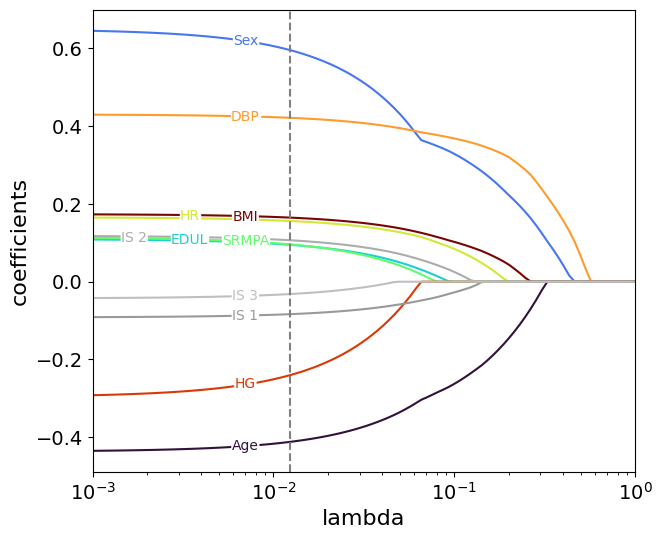

[-0.41196306  0.59575173  0.09489123  0.09606856  0.15617923  0.42144465
 -0.24048172  0.16485081 -0.08351148  0.10659953 -0.03180758]
0.021367620339748927


In [156]:
df = main_test[["Age", "Sex", "EDUL", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA", "IS_1", "IS_2", "IS_3"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Sex", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI", "IS_1", "IS_2", "IS_3"]]
Y = df["BA"]
columns = ["Age", "Sex", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI", "IS 1", "IS 2", "IS 3"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas, random_state=888).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)


# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,6))
grey_shades = np.linspace(0.6, 0.75, 3)  # Three shades of mid-grey

num_colorful = 8  # First 7 columns use the colormap
num_grey = 3  # Last 3 columns use shades of grey

for i, column in enumerate(columns):
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3  # Different grey shades for last 3
    
    plt.plot(alphas, coefs[column], label=column, color=color)



for i, column in enumerate(columns):
    y_pos = coefficients[i]
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3
    
    if i == 0:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, -6),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, 4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(-40, 1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(-40, 1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, -9),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 9:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(-80, -1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 10:
        plt.annotate(column, (0.007, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))


plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 1)
plt.ylabel('coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
#plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.savefig('eduvallassosr.png', format='png', dpi=800)
plt.show()


# Print the coefficients
print(coefficients)
print(r_squared)